<a href="https://colab.research.google.com/github/Segn11/datasciencebootcamp_project/blob/crypto_pred/crpto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
TRAIN_FILE_ID = "14FMzQx-pwRrn65V7x85MG50U_tXDtPbW"
TEST_FILE_ID = "15Hs_kf7MyC6vd4o9ul-sBGtiWV0nmbgB"

In [2]:
import gdown


# Construct the full Google Drive URLs
train_url = f"https://drive.google.com/uc?id={TRAIN_FILE_ID}"
test_url = f"https://drive.google.com/uc?id={TEST_FILE_ID}"

gdown.download(train_url, "train.csv", quiet=False)
gdown.download(test_url, "test.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=14FMzQx-pwRrn65V7x85MG50U_tXDtPbW
To: /content/train.csv
100%|██████████| 3.43M/3.43M [00:00<00:00, 20.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=15Hs_kf7MyC6vd4o9ul-sBGtiWV0nmbgB
To: /content/test.csv
100%|██████████| 1.65M/1.65M [00:00<00:00, 80.6MB/s]


'test.csv'

Variable definitions

* asset_id: An asset ID. We refer to all supported cryptocurrencies as assets
* open: Open price for the time period
* close: Close price for the time period
* high: Highest price of the time period
* low: Lowest price of the time period
* volume: Number of tweets
* market_cap: Total available supply multiplied by the current price in USD
* url_shares: Every time an identified relevant URL is shared within relevant social posts that contain relevant terms
* unique_url_shares: Number of unique url shares posted and collected on social media
* reddit_posts: Number of latest Reddit posts for supported coins
* reddit_posts_score: Reddit Karma score on individual posts
* reddit_comments: Comments on Reddit that contain relevant terms
* Reddit_comments_score: Reddit Karma score on comments
* tweets: Number of crypto-specific tweets based on tuned search and filtering criteria
* tweet_spam: Number of tweets classified as spam
* tweet_followers: Number of followers on selected tweets
* tweet_quotes: Number of quotes on selected tweets
* tweet_retweets: Number of retweets of selected tweets
* tweet_replies: Number of replies on selected tweets
* tweet_favorites: Number of likes on an individual social post that contains a relevant term
* tweet_sentiment1: Number of tweets which has a sentiment of “very bullish”
* tweet_sentiment2: Number of tweets which has a sentiment of “bullish”
* tweet_sentiment3: Number of tweets which has a sentiment of “neutral”
* tweet_sentiment4: Number of tweets which has a sentiment of “bearish”
* tweet_sentiment5: Number of tweets which has a sentiment of “very bearish”
* tweet_sentiment_impact1: “Very bearish” sentiment impact
* tweet_sentiment_impact2: “Bearish” sentiment impact
* tweet_sentiment_impact3: “Neutral” sentiment impact
* tweet_sentiment_impact4: “Bullish” sentiment impact
* tweet_sentiment_impact5: “Very bullish” sentiment impact
* social_score: Sum of followers, retweets, likes, reddit karma etc of social posts collected
* average_sentiment: The average score of sentiments, an indicator of the general sentiment being spread about a coin
* news: Number of news articles for supported coins
* price_score: A score we derive from a moving average that gives the coin some indication of an upward or downward based solely on the market value
* social_impact_score: A score of the volume/interaction/impact of social to give a sense of the size of the market or awareness of the coin
* correlation_rank: The algorithm that determines the correlation of our social data to the coin price/volume
* galaxy_score: An indicator of how well a coin is doing
* volatility: Volatility indicator
* market_cap_rank: The rank based on the total available supply multiplied by the current price in USD
* percent_change_24h_rank: The rank based on the percent change in price since 24 hours ago
* volume_24h_rank: The rank based on volume in the last 24 hours
* social_volume_24h_rank: The rank based on the number of social posts that contain relevant terms in the last 24 hours
* social_score_24h_rank: The rank based on the sum of followers, retweets, likes, reddit karma etc of social posts collected in the last 24 hours
* medium: Number of Medium articles for supported coins
* youtube: Number of videos with description that contains relevant terms
* social_volume: Number of social posts that contain relevant terms
* price_btc: Exchange rate with another coin
* market_cap_global: Total available supply multiplied by the current price in USD
* percent_change_24h: Percent change in price since 24 hours ago

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# display
from IPython.display import display

# warning
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [4]:
display(train.head())

print()

display(test.head())

,id,asset_id,open,high,low,volume,market_cap,url_shares,unique_url_shares,reddit_posts,...,percent_change_24h_rank,volume_24h_rank,social_volume_24h_rank,social_score_24h_rank,medium,youtube,social_volume,percent_change_24h,market_cap_global,close
0,ID_322qz6,1,9422.849081,9428.490628,9422.849081,7.131986e+08,1.737635e+11,1689.0,817.0,55.0,...,606.0,2.0,1.0,1.0,2.0,5.0,4422,1.434516,2.818066e+11,9428.279323
1,ID_3239o9,1,7985.359278,7992.059917,7967.567267,4.004755e+08,1.426942e+11,920.0,544.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,2159,-2.459507,2.126897e+11,7967.567267
2,ID_323J9k,1,49202.033778,49394.593518,49068.057046,3.017729e+09,9.166977e+11,1446.0,975.0,72.0,...,692.0,3.0,1.0,1.0,NaN,NaN,10602,4.942448,1.530712e+12,49120.738484
3,ID_323y5P,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,285,NaN,NaN,NaN
4,ID_324kJH,1,10535.737119,10535.737119,10384.798216,1.150053e+09,1.921183e+11,1012.0,638.0,24.0,...,749.0,2.0,1.0,1.0,NaN,2.0,3996,2.609576,3.386925e+11,10384.798216


,id,asset_id,open,high,low,volume,market_cap,url_shares,unique_url_shares,reddit_posts,...,market_cap_rank,percent_change_24h_rank,volume_24h_rank,social_volume_24h_rank,social_score_24h_rank,medium,youtube,social_volume,percent_change_24h,market_cap_global
0,ID_323Sn2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN
1,ID_325SNW,1,11335.062188,11351.690956,11335.062188,1.064152e+09,2.101463e+11,1664.0,1045.0,64.0,...,1.0,711.0,2.0,1.0,1.0,1.0,1.0,7245,-0.555698,3.631052e+11
2,ID_325uzE,1,6322.560756,6328.362354,6294.714484,1.516268e+09,1.153862e+11,397.0,255.0,11.0,...,1.0,715.0,2.0,1.0,1.0,NaN,NaN,2702,1.689370,1.771075e+11
3,ID_328qCx,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225,NaN,NaN
4,ID_3293uJ,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59,NaN,NaN


### Metadata of the data

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12632 entries, 0 to 12631
Data columns (total 49 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       12632 non-null  object 
 1   asset_id                 12632 non-null  int64  
 2   open                     8617 non-null   float64
 3   high                     8617 non-null   float64
 4   low                      8617 non-null   float64
 5   volume                   8605 non-null   float64
 6   market_cap               8379 non-null   float64
 7   url_shares               8575 non-null   float64
 8   unique_url_shares        8575 non-null   float64
 9   reddit_posts             12391 non-null  float64
 10  reddit_posts_score       12391 non-null  float64
 11  reddit_comments          12402 non-null  float64
 12  reddit_comments_score    12402 non-null  float64
 13  tweets                   8584 non-null   float64
 14  tweet_spam            

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6222 entries, 0 to 6221
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       6222 non-null   object 
 1   asset_id                 6222 non-null   int64  
 2   open                     4304 non-null   float64
 3   high                     4304 non-null   float64
 4   low                      4304 non-null   float64
 5   volume                   4302 non-null   float64
 6   market_cap               4191 non-null   float64
 7   url_shares               4285 non-null   float64
 8   unique_url_shares        4285 non-null   float64
 9   reddit_posts             6122 non-null   float64
 10  reddit_posts_score       6122 non-null   float64
 11  reddit_comments          6109 non-null   float64
 12  reddit_comments_score    6109 non-null   float64
 13  tweets                   4289 non-null   float64
 14  tweet_spam              

<Axes: >

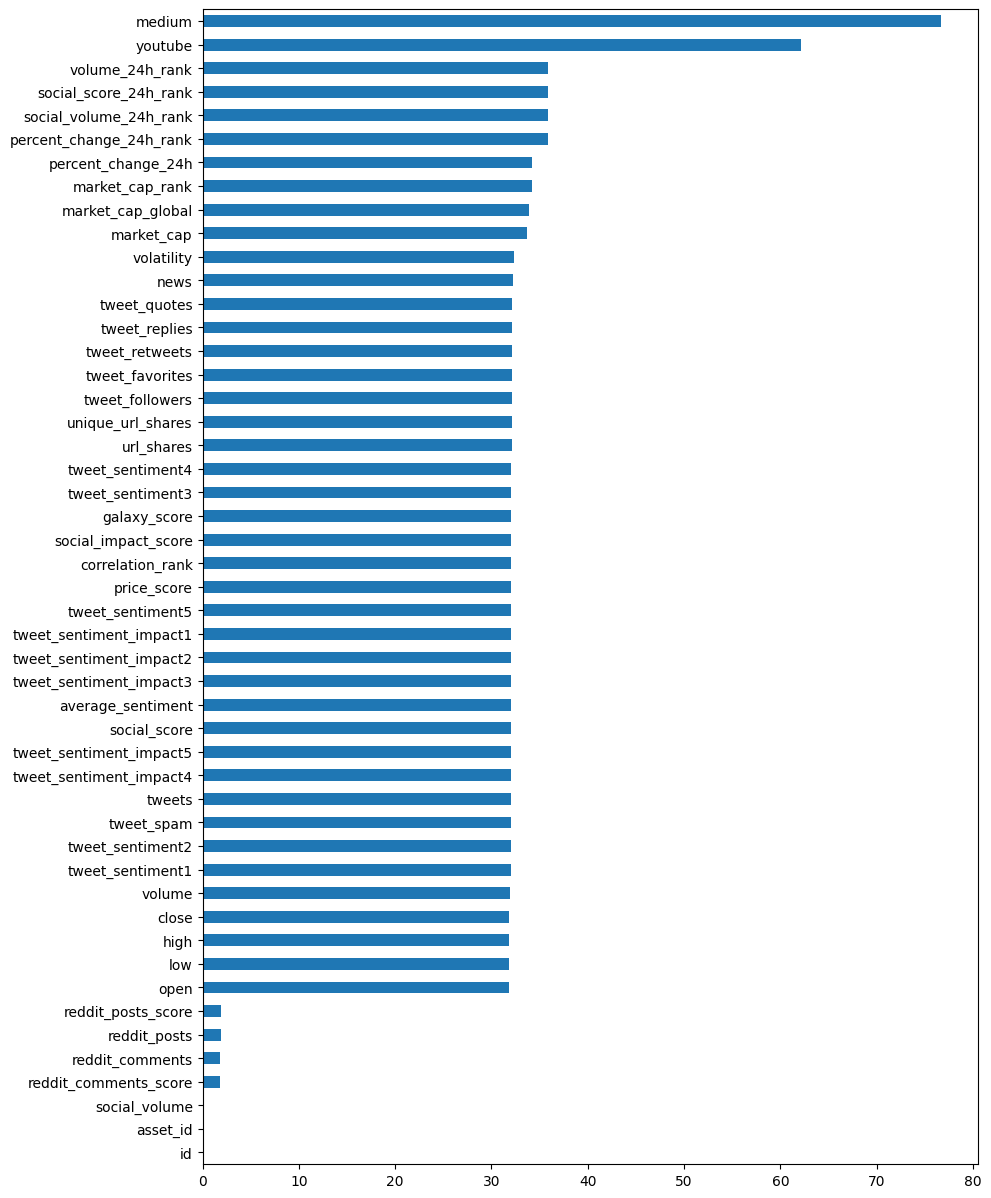

In [7]:
plt.figure(figsize=(10, 15))
(train.isna().sum() / len(train) * 100).sort_values().plot(kind="barh")


<Axes: >

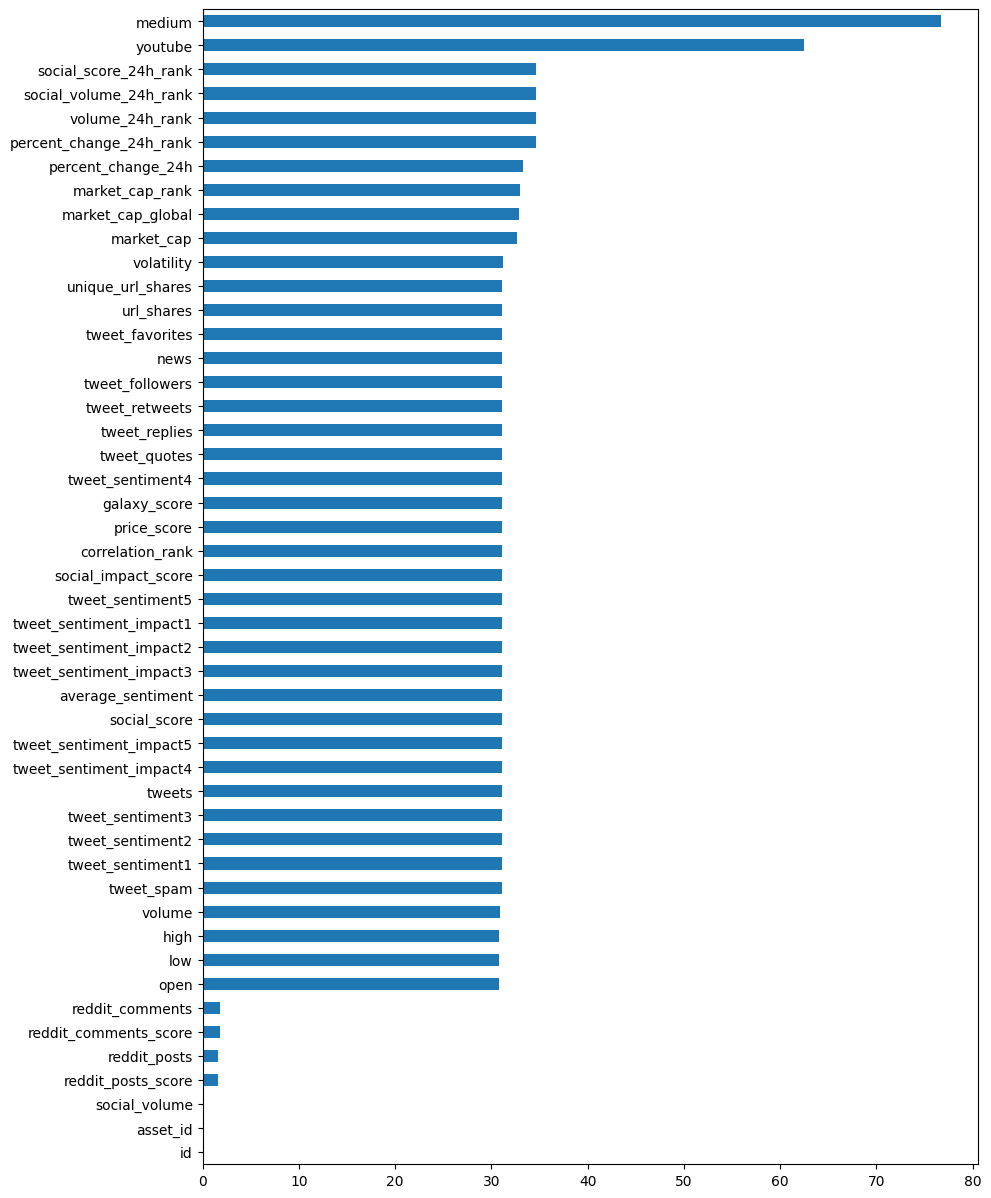

In [8]:
plt.figure(figsize=(10, 15))
(test.isna().sum() / len(test) * 100).sort_values().plot(kind="barh")

In [9]:
for col in train.columns:
    print(f"{col}: {train[col].nunique()}")

id: 12632
asset_id: 1
open: 8581
high: 8580
low: 8581
volume: 8568
market_cap: 8346
url_shares: 2128
unique_url_shares: 1342
reddit_posts: 202
reddit_posts_score: 1502
reddit_comments: 471
reddit_comments_score: 1330
tweets: 5119
tweet_spam: 3174
tweet_followers: 8536
tweet_quotes: 744
tweet_retweets: 2948
tweet_replies: 1926
tweet_favorites: 5445
tweet_sentiment1: 650
tweet_sentiment2: 1463
tweet_sentiment3: 1533
tweet_sentiment4: 4373
tweet_sentiment5: 843
tweet_sentiment_impact1: 7764
tweet_sentiment_impact2: 8534
tweet_sentiment_impact3: 8535
tweet_sentiment_impact4: 8549
tweet_sentiment_impact5: 8531
social_score: 8532
average_sentiment: 14
news: 122
price_score: 41
social_impact_score: 36
correlation_rank: 37
galaxy_score: 98
volatility: 8499
market_cap_rank: 4
percent_change_24h_rank: 1097
volume_24h_rank: 7
social_volume_24h_rank: 2
social_score_24h_rank: 2
medium: 11
youtube: 50
social_volume: 5800
percent_change_24h: 8303
market_cap_global: 8318
close: 8581


<Axes: >

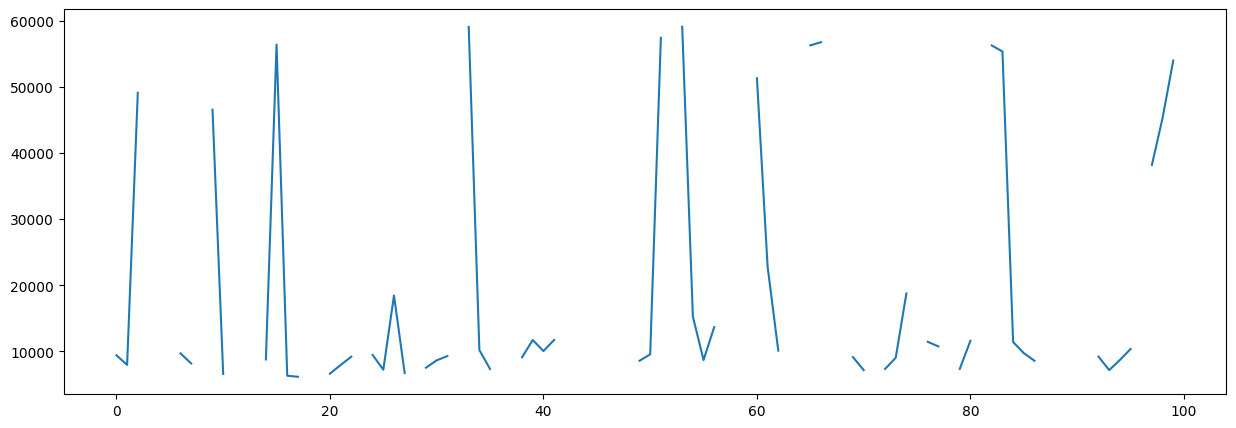

In [10]:
# plot train Close price values

train[:100].close.plot(figsize=(15, 5), kind="line")

In [11]:
df_id = train[["id", "asset_id"]].copy()
test_id1 = test[["id", "asset_id"]].copy()
test_id = test["id"].copy()

# Prepare data
X_df = train.drop(columns=["id", "asset_id", "close"]).copy()
X_te = test.drop(columns=["id", "asset_id"]).copy()

# Combine train and test data
all_data = pd.concat([X_df, X_te],ignore_index=True).reset_index(drop=True)


In [12]:
all_data.head()

,open,high,low,volume,market_cap,url_shares,unique_url_shares,reddit_posts,reddit_posts_score,reddit_comments,...,market_cap_rank,percent_change_24h_rank,volume_24h_rank,social_volume_24h_rank,social_score_24h_rank,medium,youtube,social_volume,percent_change_24h,market_cap_global
0,9422.849081,9428.490628,9422.849081,7.131986e+08,1.737635e+11,1689.0,817.0,55.0,105.0,61.0,...,1.0,606.0,2.0,1.0,1.0,2.0,5.0,4422,1.434516,2.818066e+11
1,7985.359278,7992.059917,7967.567267,4.004755e+08,1.426942e+11,920.0,544.0,20.0,531.0,103.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2159,-2.459507,2.126897e+11
2,49202.033778,49394.593518,49068.057046,3.017729e+09,9.166977e+11,1446.0,975.0,72.0,1152.0,187.0,...,1.0,692.0,3.0,1.0,1.0,NaN,NaN,10602,4.942448,1.530712e+12
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.0,424.0,268.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,285,NaN,NaN
4,10535.737119,10535.737119,10384.798216,1.150053e+09,1.921183e+11,1012.0,638.0,24.0,42.0,50.0,...,1.0,749.0,2.0,1.0,1.0,NaN,2.0,3996,2.609576,3.386925e+11


In [13]:
all_data.isna().sum()/len(all_data)*100

,0
open,31.468123
high,31.468123
low,31.468123
volume,31.542378
market_cap,33.329797
url_shares,31.791662
unique_url_shares,31.791662
reddit_posts,1.808635
reddit_posts_score,1.808635
reddit_comments,1.819243


In [14]:
for c in all_data:
  if c in all_data.columns:
    all_data[c] = all_data[c].fillna("0")


In [15]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18854 entries, 0 to 18853
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   open                     18854 non-null  object
 1   high                     18854 non-null  object
 2   low                      18854 non-null  object
 3   volume                   18854 non-null  object
 4   market_cap               18854 non-null  object
 5   url_shares               18854 non-null  object
 6   unique_url_shares        18854 non-null  object
 7   reddit_posts             18854 non-null  object
 8   reddit_posts_score       18854 non-null  object
 9   reddit_comments          18854 non-null  object
 10  reddit_comments_score    18854 non-null  object
 11  tweets                   18854 non-null  object
 12  tweet_spam               18854 non-null  object
 13  tweet_followers          18854 non-null  object
 14  tweet_quotes             18854 non-nul

In [16]:
# feature selection

drop_cols = [

    'market_cap',
    'market_cap_global',
    'percent_change_24h',
    'volatility',
    'percent_change_24h_rank',
    'news',
    'correlation_rank',
    'reddit_comments_score',
    'social_volume_24h_rank',
    'price_score',
    'galaxy_score',
    'market_cap_rank',
    'social_score_24h_rank',
    'social_impact_score',
    'average_sentiment',
    'youtube'
]

In [17]:
all_data = all_data.drop(columns=drop_cols)


In [21]:
n_train = X_df.shape[0]
X_train = all_data.iloc[:n_train, :].copy()
X_test  = all_data.iloc[n_train:, :].copy()
y_train = train["close"].copy()

In [25]:
# Combine X_train and y_train temporarily
train_data = X_train.copy()
train_data["close"] = y_train

# Drop rows where 'close' is NaN
train_data = train_data.dropna(subset=["close"])

# Split back
X_train = train_data.drop(columns=["close"])
y_train = train_data["close"]

In [29]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(y_train)
print("Mean apt price:", round(y_mean, 2))

print("Baseline MAE:", mean_absolute_error(y_train, y_pred_baseline))

Mean apt price: 15507.4
Baseline MAE: 9739.141307408157


In [26]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(
)
model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_train)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("mae:", mean_absolute_error(y_train, y_pred))


mae: 26.81367404654783


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

model.fit(X_tr, y_tr)
y_pred = model.predict(X_val)

mae_val = mean_absolute_error(y_val, y_pred)
print("Validation MAE:", mae_val)


Validation MAE: 27.051704541288768


In [31]:
y_p_test = model.predict(X_test)

submission = pd.DataFrame({
    "ID": test_id,
    "close": y_p_test
})
submission.to_csv("submission.csv", index=False)
print("✅ Submission saved!")

✅ Submission saved!


In [33]:
submission.head()

,ID,close
0,ID_323Sn2,3.863528
1,ID_325SNW,11355.719193
2,ID_325uzE,6307.279338
3,ID_328qCx,4.204973
4,ID_3293uJ,5.775457


In [34]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>